# Performer FAVOR+ Attention Head Replacement in TinyLlama 1.1B Model - Computation speed and approximation convergence analysis


In [28]:
import sys, os, time
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import copy
import matplotlib.pyplot as plt

## Setup

In [2]:
!git clone https://github.com/Antoinechss/Performer-attention-LLM.git
!pip install -q "transformers>=4.40.0" accelerate sentencepiece protobuf

REPO_DIR = "/content/Performer-attention-LLM"

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Triton available: ", end="")
try:
    import triton; print("Yes")
except ImportError:
    print("No")

Cloning into 'Performer-attention-LLM'...
remote: Enumerating objects: 271, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 271 (delta 98), reused 234 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (271/271), 1.45 MiB | 8.46 MiB/s, done.
Resolving deltas: 100% (98/98), done.
GPU: Tesla T4
Triton available: Yes


In [3]:
sys.path.insert(0, os.path.join(REPO_DIR, 'performer'))
from performer_attention import PerformerAttentionCore, _HAS_TRITON

# ── Config ──────────────────────────────────────────────────────
MODEL          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
PROMPT         = "<|user|>\nHow do I get a good night's sleep?</s>\n<|assistant|>\n"
MAX_NEW_TOKENS = 30
DTYPE          = torch.float16
DEVICE         = "cuda"

print(f"Triton kernel loaded: {_HAS_TRITON}")
print(f"Device: {DEVICE}, dtype: {DTYPE}")

Triton kernel loaded: True
Device: cuda, dtype: torch.float16


## Mixed performer / classic attention heads wrapper class

In [4]:
class MixedPerformerAttention(torch.nn.Module):
    """Wraps a HuggingFace LlamaAttention, routing some heads through FAVOR+."""

    def __init__(self, original_attn, num_performer_heads):
        super().__init__()
        self.original = original_attn
        self.head_dim = original_attn.head_dim
        self.num_heads = original_attn.config.num_attention_heads
        self.num_key_value_heads = original_attn.config.num_key_value_heads
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.scaling = self.head_dim ** -0.5
        self.num_performer_heads = num_performer_heads
        self.num_standard_heads = self.num_heads - num_performer_heads

        self.q_proj = original_attn.q_proj
        self.k_proj = original_attn.k_proj
        self.v_proj = original_attn.v_proj
        self.o_proj = original_attn.o_proj

        self.performer_core = PerformerAttentionCore(
            head_dim=self.head_dim, num_features=256
        ).to(DEVICE)

        self.config = original_attn.config
        self.layer_idx = original_attn.layer_idx
        self.is_causal = True

    def _rotate_half(self, x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)

    def _apply_rotary(self, q, k, cos, sin):
        cos = cos.unsqueeze(1)
        sin = sin.unsqueeze(1)
        return (q * cos) + (self._rotate_half(q) * sin), (k * cos) + (self._rotate_half(k) * sin)

    def forward(self, hidden_states, position_embeddings=None,
                attention_mask=None, past_key_values=None, **kwargs):
        B, N, _ = hidden_states.shape

        q = self.q_proj(hidden_states).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        cos, sin = position_embeddings
        q, k = self._apply_rotary(q, k, cos, sin)

        if past_key_values is not None:
            k, v = past_key_values.update(k, v, self.layer_idx)

        # Expand K/V for GQA
        if self.num_key_value_groups > 1:
            k = k.repeat_interleave(self.num_key_value_groups, dim=1)
            v = v.repeat_interleave(self.num_key_value_groups, dim=1)

        # Build causal mask when HF doesn't provide one.
        # The original LlamaSdpaAttention uses is_causal=True inside SDPA,
        # but our manual attention path needs an explicit mask.
        if attention_mask is None and N > 1 and self.num_standard_heads > 0:
            key_len = k.shape[2]
            causal = torch.full((N, key_len), torch.finfo(q.dtype).min,
                                device=q.device, dtype=q.dtype)
            attention_mask = torch.triu(causal, diagonal=key_len - N + 1)[None, None]

        if self.num_standard_heads == 0:
            attn_out = self.performer_core(q, k, v)
        elif self.num_performer_heads == 0:
            scores = torch.matmul(q, k.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q.dtype)
            attn_out = torch.matmul(w, v)
        else:
            Kp = self.num_performer_heads
            out_p = self.performer_core(q[:, :Kp], k[:, :Kp], v[:, :Kp])
            q_s, k_s, v_s = q[:, Kp:], k[:, Kp:], v[:, Kp:]
            scores = torch.matmul(q_s, k_s.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q_s.dtype)
            out_s = torch.matmul(w, v_s)
            attn_out = torch.cat([out_p, out_s], dim=1)

        attn_out = attn_out.transpose(1, 2).contiguous().reshape(B, N, -1)
        return self.o_proj(attn_out), None

print("MixedPerformerAttention defined.")

Load 2 TinyLlama original models, replace some attentions heads in one of them

In [21]:
# Load 2 classic models
std_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
std_model.eval()
perf_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
perf_model.eval()

num_heads = std_model.config.num_attention_heads

# -- Tune number of attention heads replaced (0->32)
NUM_PERF_HEADS = 4
# -----------------------------------

# Monkey-patch attention layers in perf_model
for layer in perf_model.model.layers:
    layer.self_attn = MixedPerformerAttention(
        layer.self_attn, num_performer_heads=NUM_PERF_HEADS
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL)
prompt_ids = tokenizer(PROMPT, return_tensors="pt")["input_ids"].to(DEVICE)

print(f"Models loaded. Heads replaced: {NUM_PERF_HEADS}/{num_heads} performer.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Models loaded. Heads replaced: 4/32 performer.


## Baseline equivalence: original vs patched(0 performer heads)

Critical correctness test. When all heads use standard softmax (0 performer heads), the patched model must produce the same logits as the original model. If this fails, the wrapper has a bug independent of the FAVOR+ approximation.

In [ ]:
# ── Baseline equivalence: patched(0 performer) must match original ──────

for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = 0
    layer.self_attn.num_standard_heads = num_heads

with torch.no_grad():
    std_out = std_model(input_ids=prompt_ids, use_cache=False)
    perf_out = perf_model(input_ids=prompt_ids, use_cache=False)

std_logits = std_out.logits[0].float()
perf_logits = perf_out.logits[0].float()

max_diff = (std_logits - perf_logits).abs().max().item()
mean_diff = (std_logits - perf_logits).abs().mean().item()
cos_sim = F.cosine_similarity(std_logits, perf_logits, dim=-1).mean().item()

# Also check last-token distribution
std_probs = F.softmax(std_logits[-1], dim=-1)
perf_probs = F.softmax(perf_logits[-1], dim=-1)
kl = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()

print("Baseline equivalence: original vs patched(0 performer heads)")
print(f"  Max abs diff on logits:     {max_diff:.6f}")
print(f"  Mean abs diff on logits:    {mean_diff:.6f}")
print(f"  Cosine similarity (avg):    {cos_sim:.6f}")
print(f"  KL div (last token):        {kl:.6f}")

if max_diff < 0.5:
    print("  PASS")
else:
    print(f"  FAIL — max diff {max_diff:.4f}, wrapper is NOT equivalent to original!")

# Restore
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads = num_heads - NUM_PERF_HEADS

## Layerwise replacement: controlled degradation

Replace performer heads in 0, 1, 2, ... layers (first N layers fully performer, rest softmax). This shows how approximation error accumulates across layers — important for understanding what finetuning needs to recover.

In [ ]:
# ── Layerwise replacement: degradation vs number of performer layers ────

print("Layerwise replacement: first N layers fully performer, rest softmax")
print(f"Each replaced layer uses all {num_heads} heads as performer (M=256)\n")

with torch.no_grad():
    std_ref = std_model(input_ids=prompt_ids, use_cache=False)
std_logits_ref = std_ref.logits[0, -1].float()
std_probs_ref = F.softmax(std_logits_ref, dim=-1)
std_top1_id = std_logits_ref.argmax().item()

n_layers = len(perf_model.model.layers)

print(f"{'Layers':>8}  {'KL':>8}  {'cos_sim':>8}  {'p(top1)':>8}")
print("-" * 40)

for n_perf_layers in [0, 1, 2, 4, 8, 11, 22]:
    for i, layer in enumerate(perf_model.model.layers):
        if i < n_perf_layers:
            layer.self_attn.num_performer_heads = num_heads
            layer.self_attn.num_standard_heads = 0
        else:
            layer.self_attn.num_performer_heads = 0
            layer.self_attn.num_standard_heads = num_heads

    with torch.no_grad():
        out = perf_model(input_ids=prompt_ids, use_cache=False)
    logits = out.logits[0, -1].float()
    probs = F.softmax(logits, dim=-1)
    kl = F.kl_div(probs.log(), std_probs_ref, reduction='sum').item()
    cos = F.cosine_similarity(logits.unsqueeze(0), std_logits_ref.unsqueeze(0)).item()
    p_top1 = probs[std_top1_id].item()

    print(f"{n_perf_layers:>8}  {kl:>8.3f}  {cos:>8.4f}  {p_top1:>8.1%}")

# Restore
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads = num_heads - NUM_PERF_HEADS

## Prompt response per-token distribution comparison

In [22]:

for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads  = num_heads - NUM_PERF_HEADS


print(f"Generation benchmark [{NUM_PERF_HEADS}/{num_heads} performer heads]")
print(" ")
print("Reponse to prompt : How do I get a good night's sleep?")
print(" ")

W = 14
hdr = f"{'Step':>4}  {'Classic':.<{W}}  {'Performer':.<{W}}  {'p(cls)':>7}  {'p_perf(cls)':>11}  {'KL':>6}"
print(hdr)
print("-" * len(hdr))

current_ids = prompt_ids.clone()
classic_tokens, perf_tokens = [], []
kl_per_step = []

with torch.no_grad():
    for step in range(1, MAX_NEW_TOKENS + 1):
        std_out  = std_model(input_ids=current_ids,  use_cache=False)
        perf_out = perf_model(input_ids=current_ids, use_cache=False)

        std_logits  = std_out.logits[0, -1].float()
        perf_logits = perf_out.logits[0, -1].float()
        std_probs  = F.softmax(std_logits,  dim=-1)
        perf_probs = F.softmax(perf_logits, dim=-1)

        classic_id = std_logits.argmax().item()
        perf_id    = perf_logits.argmax().item()
        classic_p  = std_probs[classic_id].item()
        perf_p_cls = perf_probs[classic_id].item()
        kl         = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()

        c_tok = repr(tokenizer.decode([classic_id]))[1:-1]
        p_tok = repr(tokenizer.decode([perf_id]))[1:-1]
        print(f"{step:>4}  {c_tok:<{W}}  {p_tok:<{W}}  {classic_p:>6.1%}  {perf_p_cls:>11.1%}  {kl:>6.2f}")

        classic_tokens.append(classic_id)
        perf_tokens.append(perf_id)
        kl_per_step.append(kl)

        current_ids = torch.cat([current_ids, torch.tensor([[classic_id]], device=DEVICE)], dim=-1)
        if classic_id == tokenizer.eos_token_id:
            break

Generation benchmark [4/32 performer heads]
 
Reponse to prompt : How do I get a good night's sleep?
 
Step  Classic.......  Performer.....   p(cls)  p_perf(cls)      KL
------------------------------------------------------------------
   1  To              ,                29.2%         0.0%    7.75
   2  get             ,                96.3%         0.0%    7.72
   3  a               as               95.2%         5.5%    2.86
   4  good            ,                99.7%         0.9%    4.65
   5  night           ,                99.9%         0.0%   10.08
   6  '               ,                99.9%         8.3%    2.48
   7  s               s               100.0%         5.3%    2.94
   8  sleep           ,                99.9%         0.0%   11.67
   9  ,               ,                98.6%        13.4%    1.97
  10  here            s                24.1%         0.0%    8.36
  11  are             an               99.4%         0.0%    9.28
  12  some            ,              

## Generation quality independent speed benchmarks

In [23]:
try:
    from triton_scan import triton_scan_forward as _triton_scan_raw
    from triton_scan import triton_decode_forward as _triton_decode_raw
except ImportError:
    _triton_scan_raw = _triton_decode_raw = None

_CUDA = torch.cuda.is_available()
_dev  = torch.device("cuda" if _CUDA else "cpu")
_TRITON = _HAS_TRITON and _CUDA

H, D     = 32, 64
M_VALS   = [128, 256]
REPEATS  = 10
scale    = D ** -0.25

performer_cores = {m: PerformerAttentionCore(head_dim=D, num_features=m).to(_dev) for m in M_VALS}

def time_fn(fn, repeats=REPEATS):
    # Warmup
    fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeats * 1000

Prefill Speed Benchmark

In [25]:

print(f"Prefill step  |  H={H} D={D}")
print(" ")

SEQ_LENS = [256, 512, 1024, 2048, 4096]
_CW = 12

hdr = f"{'N':>6}  {'Classic (ms)':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr)
print("-" * len(hdr))

b1_results = []
with torch.no_grad():
    for N in SEQ_LENS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        e2e_times = {}
        for m in M_VALS:
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            e2e_times[m] = time_fn(fn)
            row += f"  {e2e_times[m]:>{_CW}.2f}"

        best = min(e2e_times.values())
        speedup = std_ms / best
        row += f"  {speedup:>7.2f}x"
        print(row)
        b1_results.append((N, std_ms, e2e_times, speedup))

Prefill step  |  H=32 D=64
 
     N  Classic (ms)    Perf M=128    Perf M=256   speedup
----------------------------------------------------------
   256     0.21          1.38          2.24     0.15x
   512     0.66          2.66          4.31     0.25x
  1024     2.25          3.79          5.94     0.59x
  2048     8.01          7.38          9.59     1.08x
  4096    37.17         12.57         19.51     2.96x


Decode speed benchmark

In [26]:
print(f"Decode step")
print("")

CACHE_SIZES = [64, 256, 1024, 4096]
_CW = 12

hdr2 = f"{'Context':>6}  {'Classic':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr2)
print("-" * len(hdr2))

with torch.no_grad():
    for N in CACHE_SIZES:
        q_new = torch.randn(1, H, 1, D, device=_dev, dtype=torch.float32)
        k_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)
        v_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)

        def std_decode():
            w = torch.softmax(torch.matmul(q_new, k_all.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v_all)

        std_ms = time_fn(std_decode)
        row = f"{N:>6}  {std_ms:>7.3f}"

        best_perf = float('inf')
        for m in M_VALS:
            core      = performer_cores[m]
            phi_k_all = core.phi(k_all * scale, is_query=False)
            kv_state  = torch.einsum("bhnm,bhnd->bhmd", phi_k_all, v_all).float()
            k_state   = phi_k_all.sum(dim=2).float()
            omega_m   = core.omega.float()

            if _TRITON and _triton_decode_raw is not None:
                fn = lambda kv=kv_state, ks=k_state, om=omega_m: \
                    _triton_decode_raw((q_new * scale).float(), om, kv, ks)
            else:
                def fn(kv=kv_state, ks=k_state, c=core):
                    phi_q = c.phi(q_new * scale, is_query=True)
                    out   = torch.einsum("bhnm,bhmd->bhnd", phi_q, kv)
                    denom = torch.einsum("bhnm,bhm->bhn", phi_q, ks) + 1e-6
                    return out / denom.unsqueeze(-1)

            t = time_fn(fn)
            best_perf = min(best_perf, t)
            row += f"  {t:>{_CW}.3f}"

        row += f"  {std_ms/best_perf:>7.2f}x"
        print(row)

Decode step

Context   Classic    Perf M=128    Perf M=256   speedup
-------------------------------------------------------
    64    0.140         0.257         0.554     0.54x
   256    0.252         0.261         0.550     0.97x
  1024    0.123         0.271         0.550     0.45x
  4096    0.382         0.264         0.550     1.45x


Plots for speed comparaison

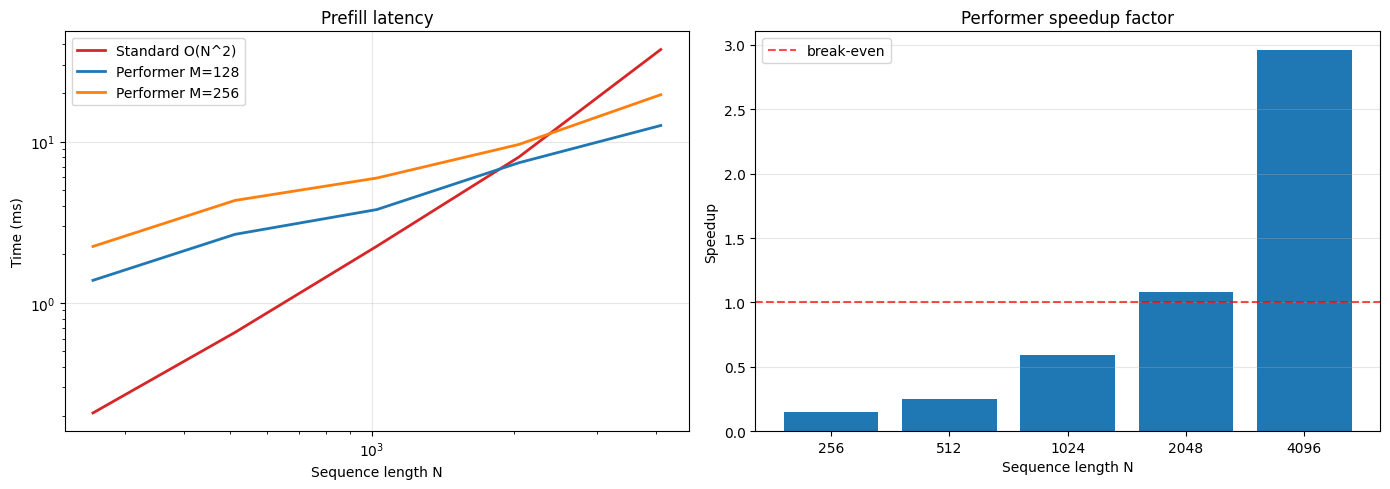

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prefill scaling
ax = axes[0]
ns = [r[0] for r in b1_results]
std_times = [r[1] for r in b1_results]
ax.plot(ns, std_times, label='Standard O(N^2)', linewidth=2, color='tab:red')
for m in M_VALS:
    perf_times = [r[2][m] for r in b1_results]
    ax.plot(ns, perf_times, label=f'Performer M={m}', linewidth=2)
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Prefill latency')
ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot speedup
ax2 = axes[1]
speedups = [r[3] for r in b1_results]
ax2.bar([str(n) for n in ns], speedups)
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='break-even')
ax2.set_xlabel('Sequence length N')
ax2.set_ylabel('Speedup')
ax2.set_title('Performer speedup factor')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Speed convergence for close M and N dimensions


**Fix M, vary N (small N regime):** When N is small, the quadratic cost N^2 is cheap, so performer offers no speedup

In [10]:
N_VALS = [32, 64, 128, 256, 512, 1024, 2048, 4096]
E1_M_VALS = [64, 128]


print(f"Fix M, vary N  |  H={H} D={D}")
print("")

hdr = f"{'N':>6}  {'Classic':>8}" + "".join(f"  {'Performer M='+str(m):>10}" for m in E1_M_VALS)
print(hdr)
print("-" * len(hdr))

e1_results = []  # list of (N, std_ms, {m: perf_ms})

with torch.no_grad():
    for N in N_VALS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        perf_times = {}
        for m in E1_M_VALS:
            if m not in performer_cores:
                performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            perf_times[m] = time_fn(fn)
            row += f"  {perf_times[m]:>9.2f}"

        print(row)
        e1_results.append((N, std_ms, perf_times))


Fix M, vary N  |  H=32 D=64

     N   Classic  Performer M=64  Performer M=128
-------------------------------------------------
    32     0.20       1.14       1.33
    64     0.21       1.21       1.11
   128     0.19       2.45       1.37
   256     0.21       1.91       1.40
   512     0.66       3.39       2.37
  1024     2.15       6.50       4.64
  2048     7.89       8.62       5.94
  4096    35.77      16.83      11.68


**Fix N, vary M:** As M increases, performer cost O(N*M) grows linearly. When M reaches N, the cost equals O(N^2) same as standard attention.

In [33]:
N = 2048
M_VALS = [32, 64, 128, 256, 512, 1024, 2048]

# ---------------------------------------------
# Standard attention baseline for this N
# ---------------------------------------------
with torch.no_grad():
    q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
    k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
    v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

    def std_attn():
        w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
        return torch.matmul(w, v)

    e2_std_ms = time_fn(std_attn)
print(f"Standard attention baseline at N={N}: {e2_std_ms:.2f} ms\n")


print(f"{'M':>6}  {'M/D':>5}  {'M/N':>5}  {'Perf(ms)':>9}  {'Speedup':>8}")
print("-" * 45)

e2_results = []

with torch.no_grad():
    for m in M_VALS:
        if m not in performer_cores:
            performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
        core = performer_cores[m]
        fn = lambda c=core: c(q, k, v)
        perf_ms = time_fn(fn)
        speedup = e2_std_ms / perf_ms

        print(f"{m:>6}  {m/D:>5.1f}  {m/N:>5.2f}  {perf_ms:>8.2f}  {speedup:>7.2f}x")
        e2_results.append((m, perf_ms, speedup))


Standard attention baseline at N=2048: 9.41 ms

     M    M/D    M/N   Perf(ms)   Speedup
---------------------------------------------
    32    0.5   0.02      5.29     1.49x
    64    1.0   0.03     12.49     0.63x
   128    2.0   0.06      6.08     1.30x
   256    4.0   0.12      9.79     0.81x
   512    8.0   0.25    134.10     0.06x
  1024   16.0   0.50    650.99     0.01x
  2048   32.0   1.00   1284.87     0.01x


Plots for computation speed convergence

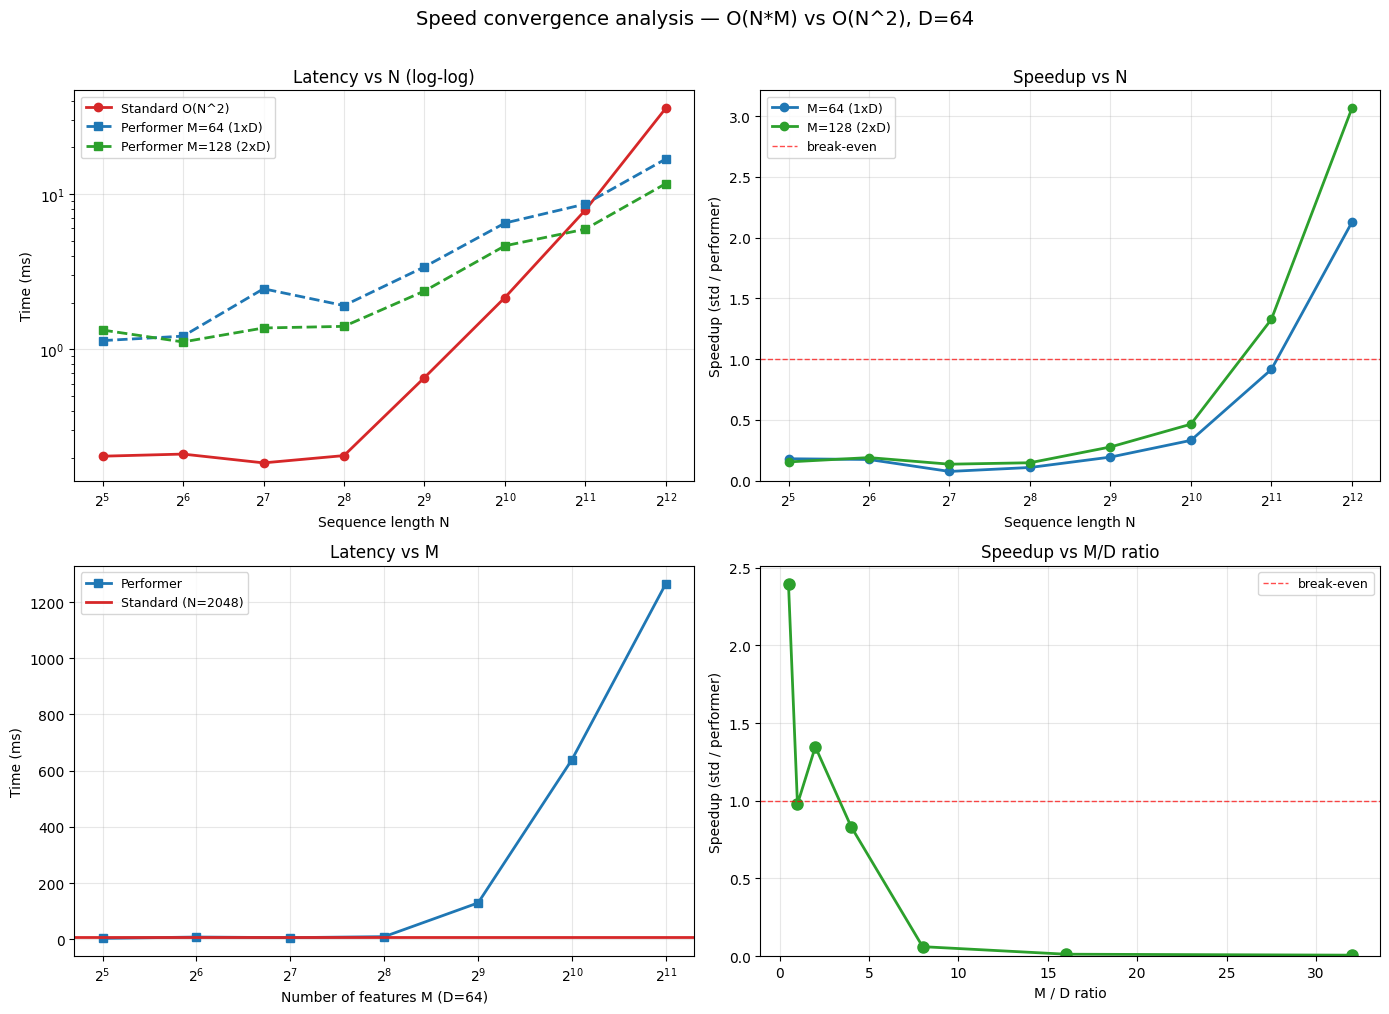

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------
# Latency curves vs N (log-log scale)
# -----------------------------------

ax = axes[0, 0]
e1_ns = [r[0] for r in e1_results]
e1_std = [r[1] for r in e1_results]
ax.plot(e1_ns, e1_std, 'o-', label='Standard O(N^2)', linewidth=2, color='tab:red')
colors = ['tab:blue', 'tab:green', 'tab:purple']
for i, m in enumerate(E1_M_VALS):
    perf = [r[2][m] for r in e1_results]
    ax.plot(e1_ns, perf, 's--', label=f'Performer M={m} ({m//D}xD)', linewidth=2, color=colors[i])
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Latency vs N (log-log)')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# -----------------------------------
# Speedup vs N
# -----------------------------------

ax = axes[0, 1]
for i, m in enumerate(E1_M_VALS):
    speedups = [r[1] / r[2][m] for r in e1_results]
    ax.plot(e1_ns, speedups, 'o-', label=f'M={m} ({m//D}xD)', linewidth=2, color=colors[i])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup vs N')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# -----------------------------------
# Latency vs M
# -----------------------------------

ax = axes[1, 0]
e2_ms = [r[0] for r in e2_results]
e2_perf = [r[1] for r in e2_results]
ax.plot(e2_ms, e2_perf, 's-', label='Performer', linewidth=2, color='tab:blue')
ax.axhline(y=e2_std_ms, color='tab:red', linewidth=2, label=f'Standard (N={N})')
ax.set_xlabel(f'Number of features M (D={D})')
ax.set_ylabel('Time (ms)')
ax.set_title('Latency vs M')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# -----------------------------------
# Speedup vs M/D ratio
# -----------------------------------

ax = axes[1, 1]
e2_md_ratios = [m / D for m in e2_ms]
e2_speedups = [r[2] for r in e2_results]
ax.plot(e2_md_ratios, e2_speedups, 'o-', linewidth=2, color='tab:green', markersize=8)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('M / D ratio')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup vs M/D ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.suptitle(f'Speed convergence analysis — O(N*M) vs O(N^2), D={D}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Approximation quality analysis: M/D – Post generation

The FAVOR+ feature map approximates softmax: `phi(Q)^T phi(K) ≈ softmax(QK^T/sqrt(D))`.

The approximation quality depends on M/D (number of random features per head dimension). M controls how well we approximate the kernel `exp(q^T k)` in D-dimensional space.

Parameters :
- D = 64
- M = 256

Pre finetune : the results are weak even when D is very close to M since tiny errors propagate through the layers.

Section needs finetuning step to deliver relevant results

In [42]:
M_VALS = [16, 32, 64, 128, 256, 512, 1024]

print(f"Fix prompt (N={prompt_ids.shape[1]}), vary M (D={D})")
print("")

with torch.no_grad():
    std_out = std_model(input_ids=prompt_ids, use_cache=False)
std_logits = std_out.logits[0, -1].float()
std_probs = F.softmax(std_logits, dim=-1)
std_top5 = set(std_logits.topk(5).indices.tolist())
std_top1_id = std_logits.argmax().item()

print(" – top5 = how many of the correct tokens (from softmax attention) are still present in the top 5 predictions of Performer.")
print("")
print(" – p(top1) = Probability assigned by Performer to the true top-1 token (from softmax).")
print("")

print(f"{'M':>6}  {'M/D':>5}  {'KL':>8}  {'Top5':>5}  {'p(top1)':>8}")
print("-" * 50)

f1_results = []
for m in M_VALS:
    for layer in perf_model.model.layers:
        layer.self_attn.performer_core = PerformerAttentionCore(
            head_dim=D, num_features=m
        ).to(DEVICE)
        layer.self_attn.num_performer_heads = num_heads
        layer.self_attn.num_standard_heads = 0

    with torch.no_grad():
        perf_out = perf_model(input_ids=prompt_ids, use_cache=False)

    perf_logits = perf_out.logits[0, -1].float()
    perf_probs = F.softmax(perf_logits, dim=-1)
    kl = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()
    overlap = len(set(perf_logits.topk(5).indices.tolist()) & std_top5)
    p_top1 = perf_probs[std_top1_id].item()

    print(f"{m:>6}  {m/D:>5.1f}  {kl:>8.3f}  {overlap:>4}/5  {p_top1:>8.1%}")
    f1_results.append((m, kl, overlap, p_top1))

for layer in perf_model.model.layers:
    layer.self_attn.performer_core = PerformerAttentionCore(
        head_dim=D, num_features=256
    ).to(DEVICE)
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads = num_heads - NUM_PERF_HEADS

Fix prompt (N=28), vary M (D=64)

 – top5 = how many of the correct tokens (from softmax attention) are still present in the top 5 predictions of Performer.

 – p(top1) = Probability assigned by Performer to the true top-1 token (from softmax).

     M    M/D        KL   Top5   p(top1)
--------------------------------------------------
    16    0.2     2.979     0/5      0.2%
    32    0.5     4.994     1/5      0.0%
    64    1.0     3.987     0/5      0.2%
   128    2.0     3.380     0/5      0.6%
   256    4.0     3.640     0/5      0.3%
   512    8.0     6.887     0/5      0.0%
  1024   16.0     3.311     0/5      0.6%


Plots for post generation quality comparaison

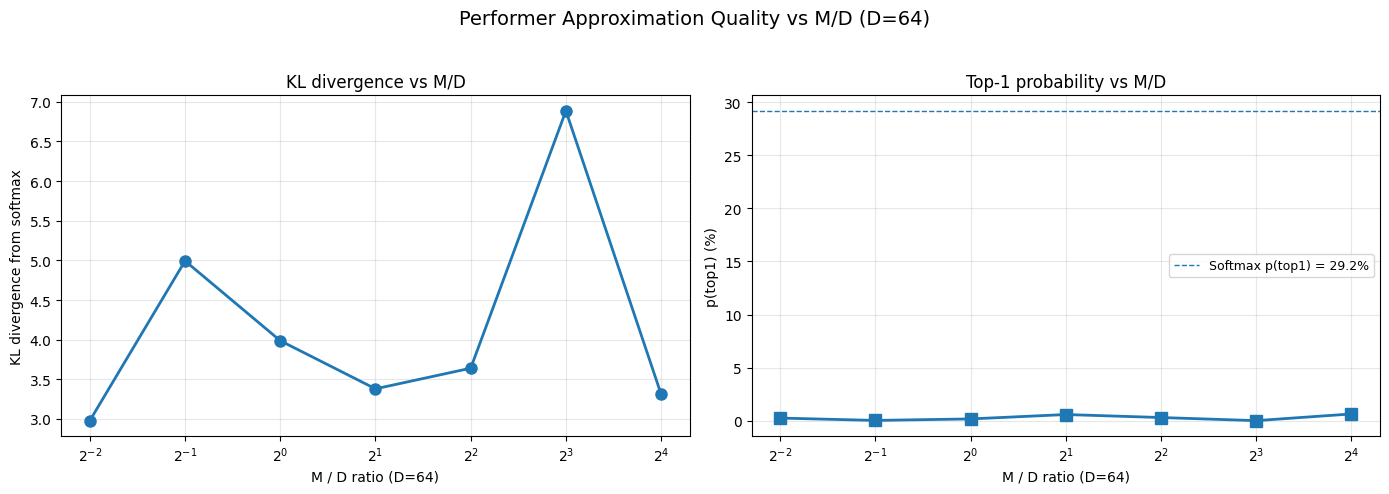

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 cols

# ---------------------------------------
# KL div vs M/D
# ---------------------------------------
ax = axes[0]

f1_ms = [r[0] for r in f1_results]
f1_md = [m / D for m in f1_ms]
f1_kls = [r[1] for r in f1_results]

ax.plot(f1_md, f1_kls, 'o-', linewidth=2, markersize=8)
ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('KL divergence from softmax')
ax.set_title('KL divergence vs M/D')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# ---------------------------------------
# p(top1) vs M/D
# ---------------------------------------
ax = axes[1]

f1_ptop1 = [r[3] * 100 for r in f1_results]
std_top1_prob = std_probs[std_top1_id].item() * 100

ax.plot(f1_md, f1_ptop1, 's-', linewidth=2, markersize=8)
ax.axhline(
    y=std_top1_prob,
    linestyle='--',
    linewidth=1,
    label=f'Softmax p(top1) = {std_top1_prob:.1f}%'
)

ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('p(top1) (%)')
ax.set_title('Top-1 probability vs M/D')
ax.set_xscale('log', base=2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(f'Performer Approximation Quality vs M/D (D={D})',fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Pre Generation mathematical approximation benchmark

This section validates the pure PAVOR+ mathematical approximation of softmax, independent of the Q and K model vectors. Simulating pretrained model Q/K norms.

In [47]:
# First redefining a standard softmaw causal attention

def causal_softmax_attention(q, k, v):
    """Standard causal softmax attention"""
    D = q.shape[-1]
    scores = torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5)
    N = q.shape[2]
    mask = torch.triu(torch.ones(N, N, device=q.device), diagonal=1).bool()
    scores.masked_fill_(mask, float('-inf'))
    w = torch.softmax(scores, dim=-1)
    return torch.matmul(w, v), w

Single-layer output comparison test

In [49]:
torch.manual_seed(42)
B, H, N_test, D_test = 1, 4, 64, 64
M_test = 256
ELEM_STD = 0.5

q = torch.randn(B, H, N_test, D_test, device=_dev, dtype=torch.float32) * ELEM_STD
k = torch.randn(B, H, N_test, D_test, device=_dev, dtype=torch.float32) * ELEM_STD
v = torch.randn(B, H, N_test, D_test, device=_dev, dtype=torch.float32)

with torch.no_grad():
    out_std, w_std = causal_softmax_attention(q, k, v)

core = PerformerAttentionCore(head_dim=D_test, num_features=M_test).to(_dev)
with torch.no_grad():
    out_perf = core(q, k, v)

mse = F.mse_loss(out_perf, out_std).item()
cos = F.cosine_similarity(out_perf.reshape(-1, D_test), out_std.reshape(-1, D_test), dim=-1).mean().item()
rel_err = (out_perf - out_std).norm() / out_std.norm()

print(f"Single-layer approximation test (B={B}, H={H}, N={N_test}, D={D_test}, M={M_test}, M/D={M_test//D_test})")
print(f"")
print(f"  MSE between outputs:         {mse:.6f}")
print(f"  Cosine similarity (avg):     {cos:.6f}")
print(f"  Relative L2 error:           {rel_err:.4f} ({rel_err*100:.1f}%)")
print(f"  Cosine similarity            {cos:.4f}")

Single-layer approximation test (B=1, H=4, N=64, D=64, M=256, M/D=4)

  MSE between outputs:         0.004248
  Cosine similarity (avg):     0.957919
  Relative L2 error:           0.2243 (22.4%)
  Cosine similarity            0.9579


Approximation evolution vs M/D ratio test

In [51]:
M_VALS = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
N = 64

torch.manual_seed(42)
q = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32) * ELEM_STD
k = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32) * ELEM_STD
v = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32)

with torch.no_grad():
    out_std, _ = causal_softmax_attention(q, k, v)

print(f"\n{'='*70}")
print(f"Fix N={N}, D={D}, and increase M/D ratio")
print(f"{'='*70}\n")
print(f"{'M':>6}  {'M/D':>5}  {'MSE':>10}  {'Cosine':>8}  {'RelErr%':>8}")
print("-" * 45)

g2_results = []
for m in M_VALS:
    mses, coss, rels = [], [], []
    for trial in range(5):
        core = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
        with torch.no_grad():
            out_perf = core(q, k, v)
        mses.append(F.mse_loss(out_perf, out_std).item())
        coss.append(F.cosine_similarity(out_perf.reshape(-1, D), out_std.reshape(-1, D), dim=-1).mean().item())
        rels.append(((out_perf - out_std).norm() / out_std.norm()).item())

    avg_mse = sum(mses) / len(mses)
    avg_cos = sum(coss) / len(coss)
    avg_rel = sum(rels) / len(rels)

    print(f"{m:>6}  {m/D:>5.1f}  {avg_mse:>10.6f}  {avg_cos:>8.4f}  {avg_rel*100:>7.2f}%")
    g2_results.append((m, avg_mse, avg_cos, avg_rel))


Fix N=64, D=64, and increase M/D ratio

     M    M/D         MSE    Cosine   RelErr%
---------------------------------------------
     8    0.1    0.046124    0.7481    73.62%
    16    0.2    0.029510    0.8081    58.98%
    32    0.5    0.020428    0.8679    49.09%
    64    1.0    0.015325    0.8938    42.00%
   128    2.0    0.009307    0.9312    33.12%
   256    4.0    0.005841    0.9534    26.19%
   512    8.0    0.003592    0.9696    20.59%
  1024   16.0    0.001995    0.9820    15.33%
  2048   32.0    0.001263    0.9901    12.21%


### In-model tensor test

Extract actual Q/K/V from a TinyLlama layer (post-RoPE) and compare causal softmax attention vs FAVOR+ on those real tensors. This validates the approximation on realistic vector distributions, not just synthetic randn.

In [ ]:
# ── In-model tensor test: real Q/K/V from TinyLlama ────────────────────
# Run the original model, intercept Q/K/V after RoPE in layer 0,
# then compare causal softmax vs FAVOR+ on those real tensors.

captured = {}

def capture_hook(module, args, kwargs):
    """Forward hook to capture hidden_states and position_embeddings."""
    hs = kwargs.get('hidden_states', args[0] if args else None)
    pe = kwargs.get('position_embeddings', None)
    if pe is None and len(args) > 1:
        pe = args[1]
    captured['hidden_states'] = hs
    captured['position_embeddings'] = pe

handle = std_model.model.layers[0].self_attn.register_forward_pre_hook(
    capture_hook, with_kwargs=True
)
with torch.no_grad():
    std_model(input_ids=prompt_ids, use_cache=False)
handle.remove()

hs = captured['hidden_states']
pe = captured['position_embeddings']
attn = std_model.model.layers[0].self_attn

B, N_t, _ = hs.shape
hd = attn.head_dim
nh = attn.config.num_attention_heads
nkv = attn.config.num_key_value_heads
nkvg = nh // nkv

q = attn.q_proj(hs).view(B, N_t, nh, hd).transpose(1, 2).float()
k = attn.k_proj(hs).view(B, N_t, nkv, hd).transpose(1, 2).float()
v = attn.v_proj(hs).view(B, N_t, nkv, hd).transpose(1, 2).float()

if pe is not None:
    cos, sin = pe
    cos_u = cos.unsqueeze(1).float()
    sin_u = sin.unsqueeze(1).float()
    def rot_half(x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)
    q = (q * cos_u) + (rot_half(q) * sin_u)
    k = (k * cos_u) + (rot_half(k) * sin_u)

if nkvg > 1:
    k = k.repeat_interleave(nkvg, dim=1)
    v = v.repeat_interleave(nkvg, dim=1)

print(f"Extracted real tensors from layer 0: q={list(q.shape)}, k={list(k.shape)}")
print(f"Q norm range: [{q.norm(dim=-1).min():.2f}, {q.norm(dim=-1).max():.2f}]")

# Standard causal softmax on real tensors
out_std, _ = causal_softmax_attention(q, k, v)

# Performer on real tensors at various M
print(f"\n{'M':>6}  {'M/D':>5}  {'cos_sim':>8}  {'rel_err%':>9}")
print("-" * 35)
for m in [64, 128, 256, 512, 1024]:
    cos_trials, rel_trials = [], []
    for _ in range(3):
        core = PerformerAttentionCore(head_dim=hd, num_features=m).to(q.device)
        with torch.no_grad():
            out_perf = core(q, k, v)
        cs = F.cosine_similarity(
            out_perf.reshape(-1, hd), out_std.reshape(-1, hd), dim=-1
        ).mean().item()
        re = ((out_perf - out_std).norm() / out_std.norm()).item()
        cos_trials.append(cs)
        rel_trials.append(re)
    avg_cos = sum(cos_trials) / len(cos_trials)
    avg_rel = sum(rel_trials) / len(rel_trials)
    print(f"{m:>6}  {m/hd:>5.1f}  {avg_cos:>8.4f}  {avg_rel*100:>8.2f}%")

Attention weight comparaison – pattern similarity

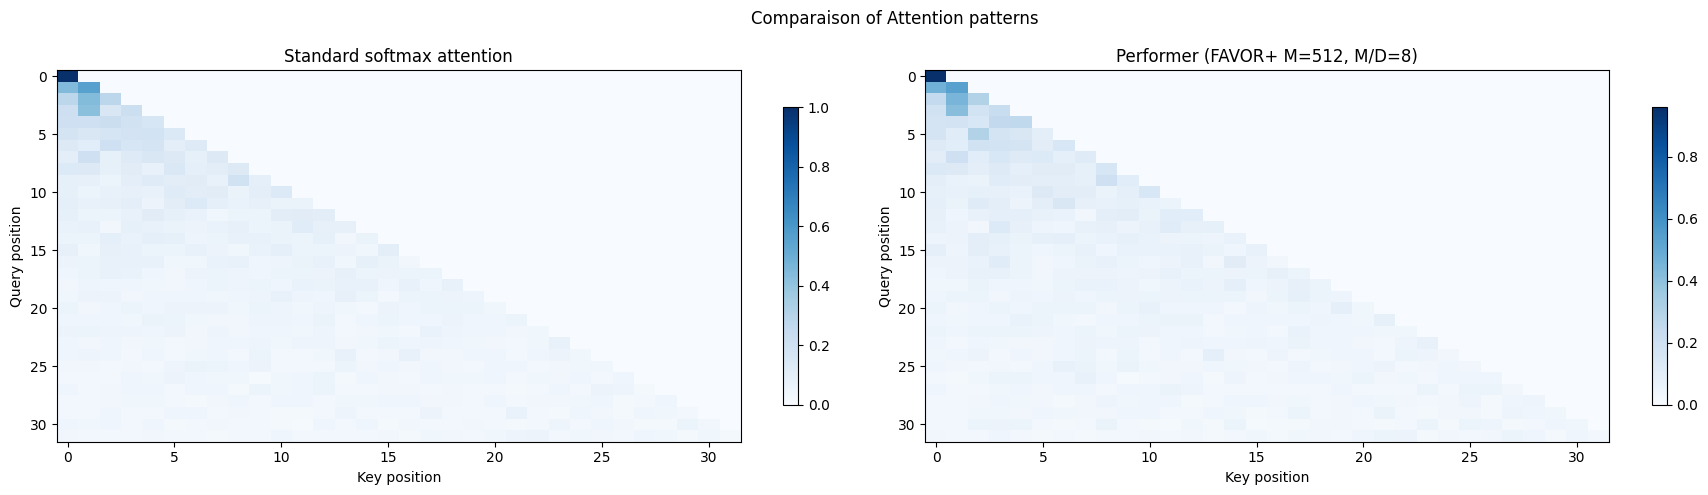

In [55]:
torch.manual_seed(42)
N_vis = 32
q = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32) * ELEM_STD
k = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32) * ELEM_STD
v = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32)

with torch.no_grad():
    _, w_std = causal_softmax_attention(q, k, v)
w_std = w_std[0, 0].cpu()

core_vis = PerformerAttentionCore(head_dim=D, num_features=512).to(_dev)
with torch.no_grad():
    scale = D ** -0.25
    phi_q = core_vis.phi(q * scale, is_query=True)
    phi_k = core_vis.phi(k * scale, is_query=False)
    w_perf = torch.matmul(phi_q, phi_k.transpose(-2, -1))[0, 0]
    causal_mask = torch.triu(torch.ones(N_vis, N_vis, device=_dev), diagonal=1).bool()
    w_perf.masked_fill_(causal_mask, 0.0)
    w_perf = w_perf / (w_perf.sum(dim=-1, keepdim=True) + 1e-6)
w_perf = w_perf.cpu()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

im0 = axes[0].imshow(w_std.numpy(), cmap='Blues', aspect='auto')
axes[0].set_title('Standard softmax attention')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(w_perf.numpy(), cmap='Blues', aspect='auto')
axes[1].set_title(f'Performer (FAVOR+ M=512, M/D={512//D})')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

diff = (w_std - w_perf).abs().numpy()

plt.suptitle('Comparaison of Attention patterns')
plt.tight_layout()
plt.show()

frob = torch.norm(w_std - w_perf, p='fro').item()

Quality convergence plots

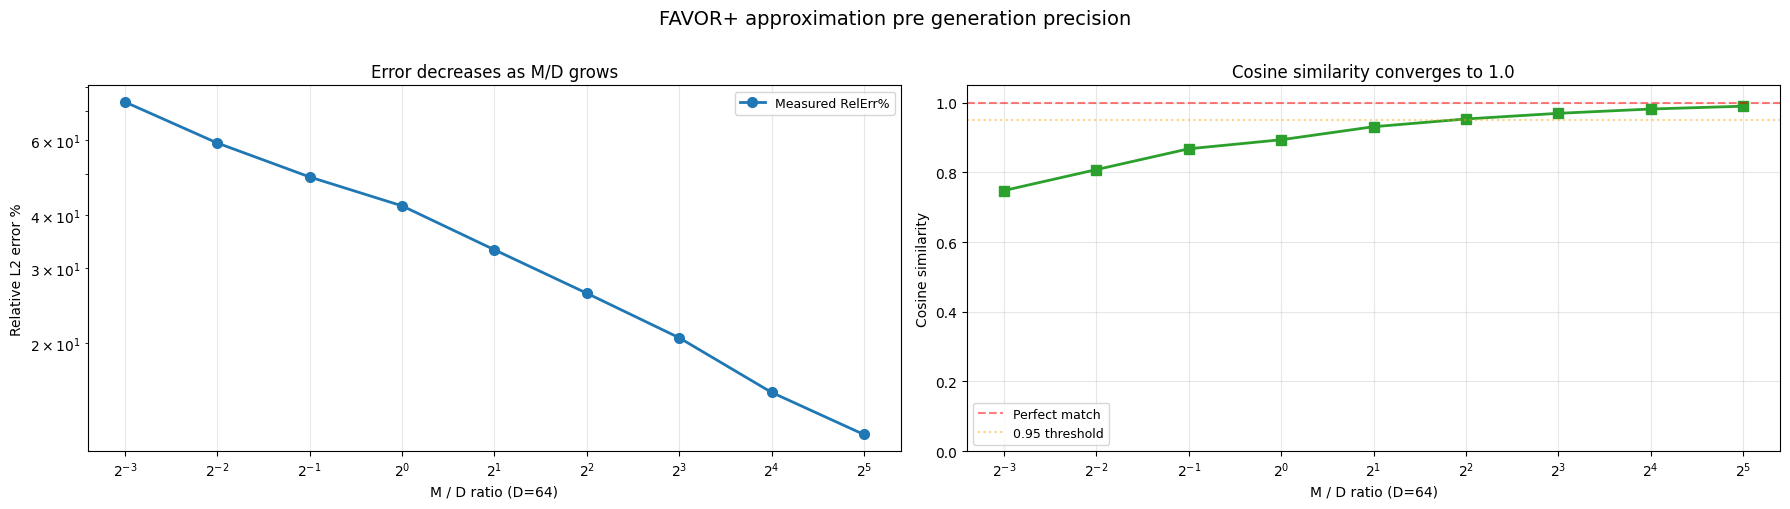

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ----------------------------
# Error vs M/D
# ----------------------------

ax = axes[0]
g2_md = [r[0] / D for r in g2_results]
g2_rels = [r[3] * 100 for r in g2_results]
ax.plot(g2_md, g2_rels, 'o-', linewidth=2, color='tab:blue', label='Measured RelErr%', markersize=7)
ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('Relative L2 error %')
ax.set_title('Error decreases as M/D grows')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ----------------------------
# Cosine vs M/D
# ----------------------------

ax = axes[1]
g2_coss = [r[2] for r in g2_results]
ax.plot(g2_md, g2_coss, 's-', linewidth=2, color='tab:green', markersize=7)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect match')
ax.axhline(y=0.95, color='orange', linestyle=':', alpha=0.5, label='0.95 threshold')
ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('Cosine similarity')
ax.set_title('Cosine similarity converges to 1.0')
ax.set_xscale('log', base=2)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FAVOR+ approximation pre generation precision', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()